In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/neptune1008/housing-price-prediction/housing.csv


In [26]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor


In [3]:
df = pd.read_csv("/kaggle/input/datasets/neptune1008/housing-price-prediction/housing.csv")

In [4]:
df


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


**DOING SOME EXPLORATORY DATA ANALYSIS**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


We can see above that there are no null values and hence we do not need to worry about the null values 

**DIVISION OF COLUMNS**

Also lets divide the columns into categorical and numerical values here it self
* Area --> numercial column
* Bedroom --> numerical column
* Bathrooms --> numerical column
* Stories --> numerical column
* Mainroad --> categorical column 
* Guest room --> categorical column 
* Basement --> categorical column 
* hotwaterheating --> categorical column 
* airconditioning --> categorical columns 
* parking --> numerical column 
* prefarea --> categorical columns 
* furnishing status --> categorical columns 



LETS CHECK THE DISTRIBUTION OF THE AREA COLUMNN 

1.321188343153483
2.7514801872608086


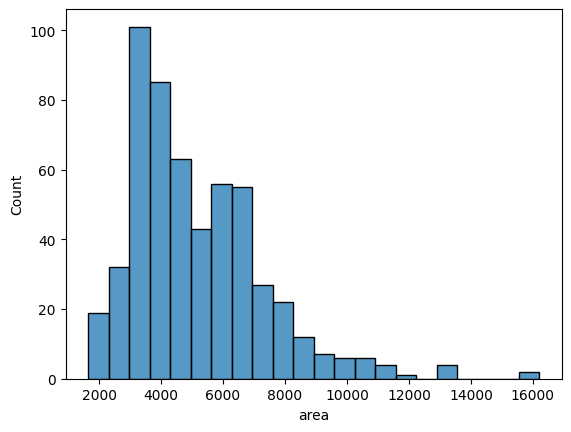

In [6]:
sns.histplot(df["area"])
print(df["area"].skew())
print(df["area"].kurt())

One can see that the skewness is 1.32 and kurtosis is 2.75 and hence the area column is right skewed. And we can apply log1p tranformation here 

In [7]:
df["area_log"] = np.log1p(df['area'])


0.13374740415416703
-0.2135484087641819


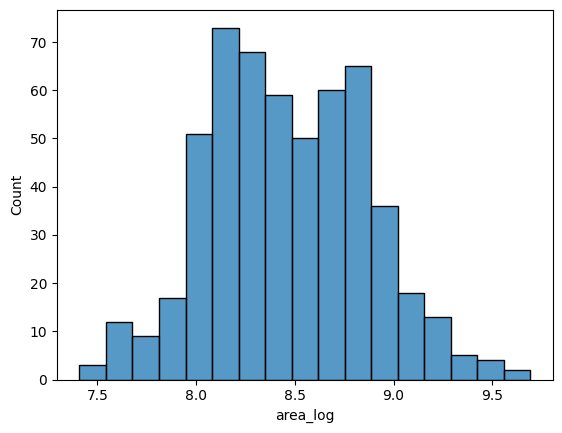

In [8]:
sns.histplot(df["area_log"])
print(df["area_log"].skew())
print(df["area_log"].kurt())

Now the skewness is 0.133 and kurtosis is -0.21 and hence the area is more normally distributed 

GRAPHICAL REPRESENTATION OF THE VALUES 


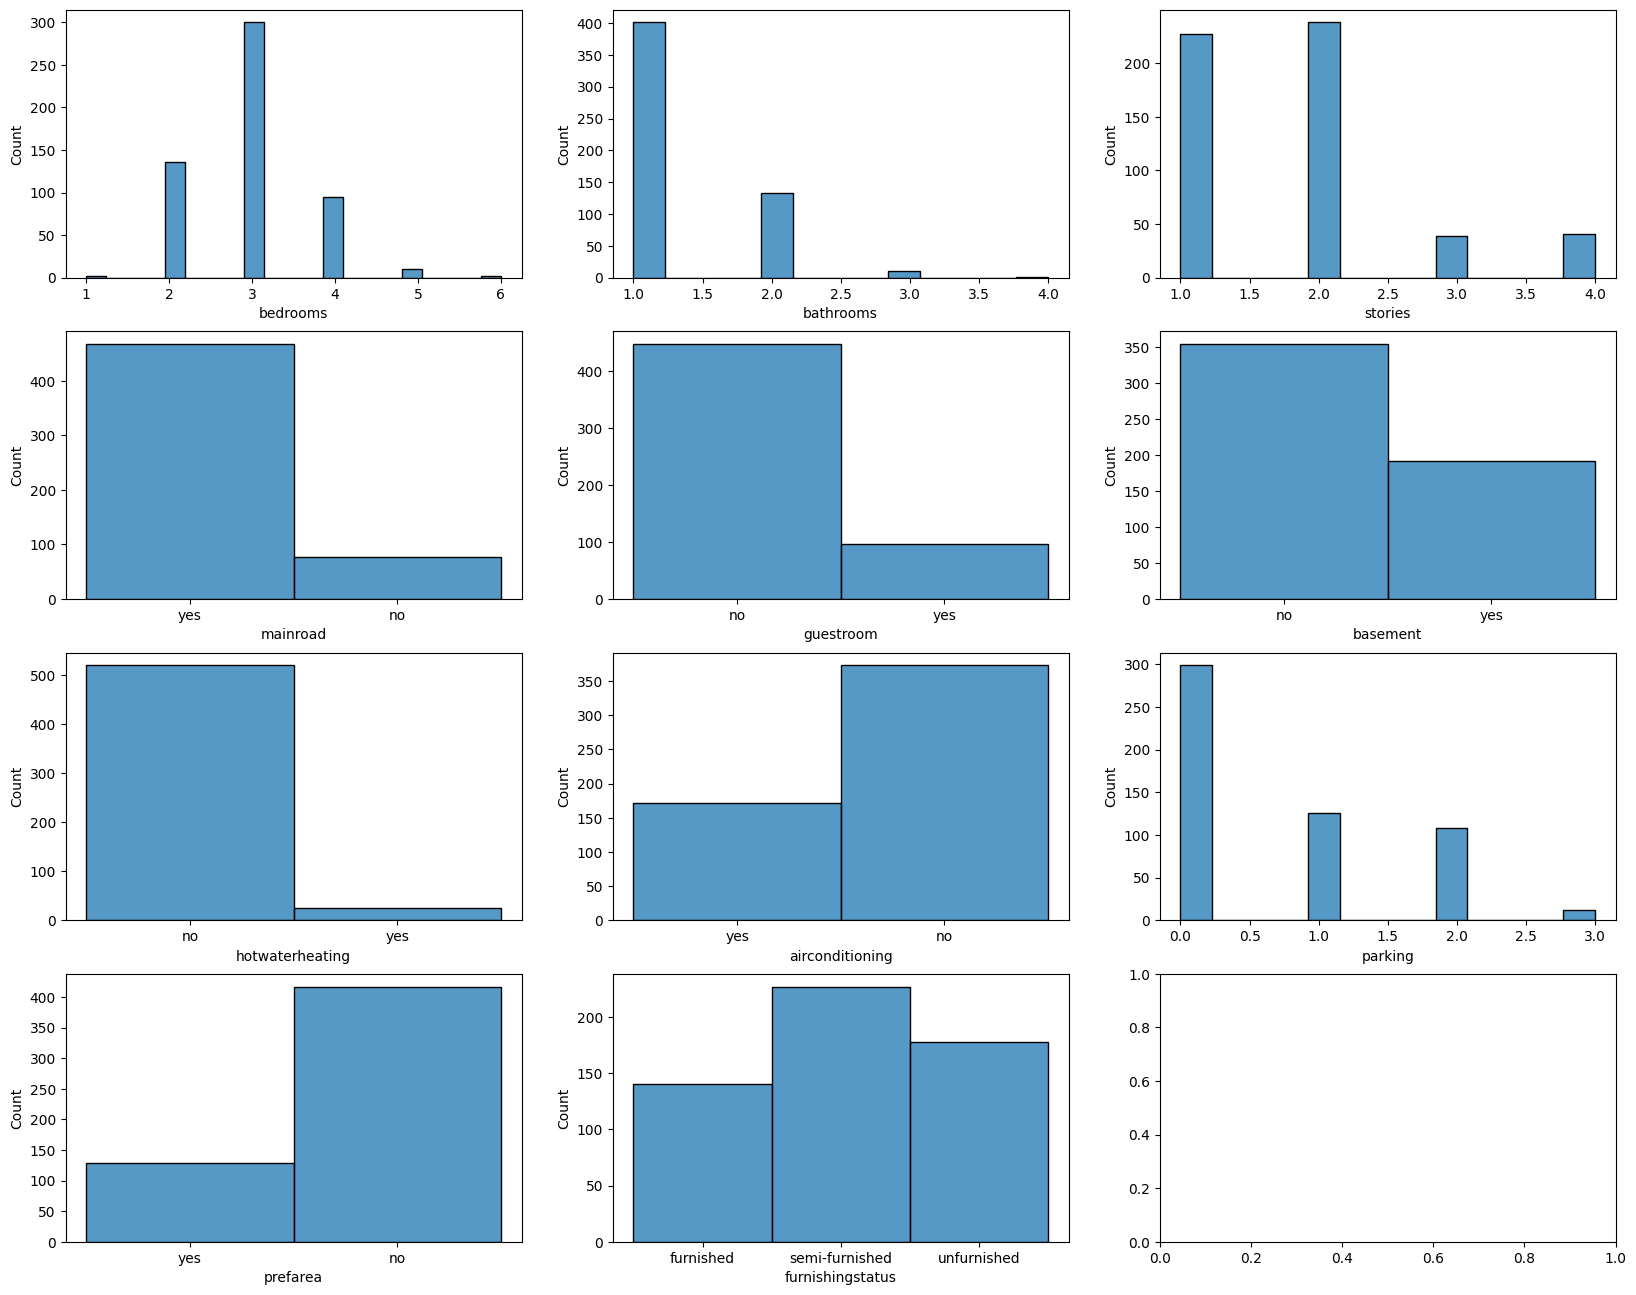

In [9]:
category_col = ['bedrooms', 'bathrooms', 'stories', 'mainroad',
               'guestroom','basement','hotwaterheating','airconditioning',
               'parking','prefarea','furnishingstatus']

fig, axes = plt.subplots(4,3,figsize=(20,16))

for i,j in zip(axes.flatten(), category_col):
    sns.histplot(df[j], ax=i, multiple="dodge")

SEE RELATION OF OTHER COLUMNS WITH THE PRICE

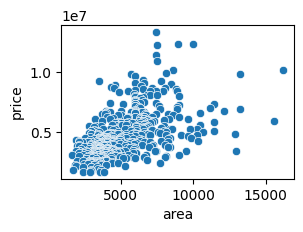

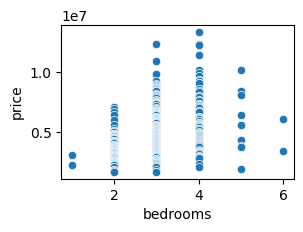

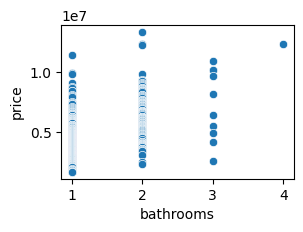

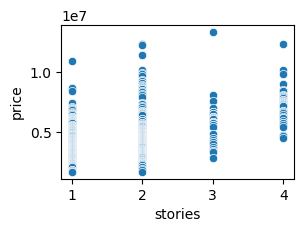

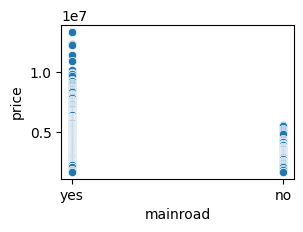

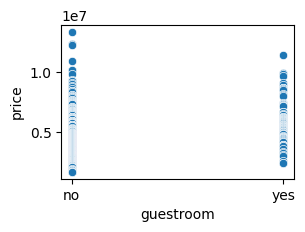

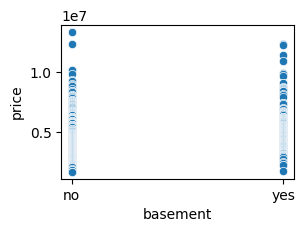

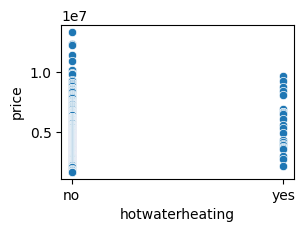

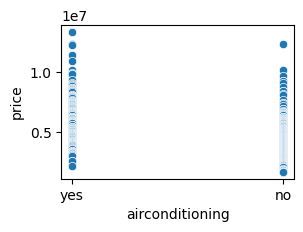

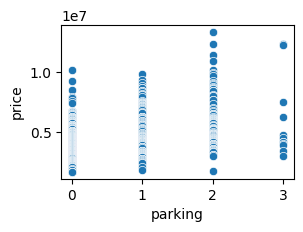

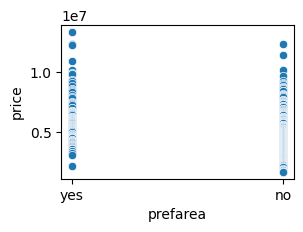

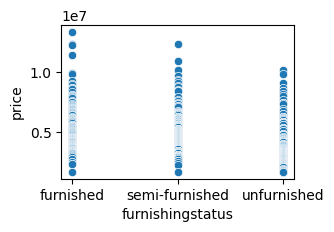

In [10]:
category_col = ['area','bedrooms', 'bathrooms', 'stories', 'mainroad',
               'guestroom','basement','hotwaterheating','airconditioning',
               'parking','prefarea','furnishingstatus']

for i in category_col:
    plt.figure(figsize=(3,2))
    sns.scatterplot(x=df[i],y=df["price"],sizes=40)
    plt.xlabel(i)
    plt.ylabel('price')
    plt.show()

Encode the categorical values 

In [11]:
df_encoded = df.copy()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

In [12]:
furnishing_map = {"unfurnished":0, "semi-furnished":1,"furnished":2}
df_encoded["furnishingstatus"] = df_encoded["furnishingstatus"].map(furnishing_map)

In [13]:
df_encoded

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_log
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,8.912069
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,9.100637
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,9.206433
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,8.922792
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,8.912069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,8.006701
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,7.783641
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,8.194506
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2,7.976252


So finally we have dealth with the numerical values and categorical values also. 
And noe we will divide it into x(as input) and y(price as output)

LETS DO NOMRALISATION OF THE PRICE ALSO 

1.2122388370279802
1.9601302314151994


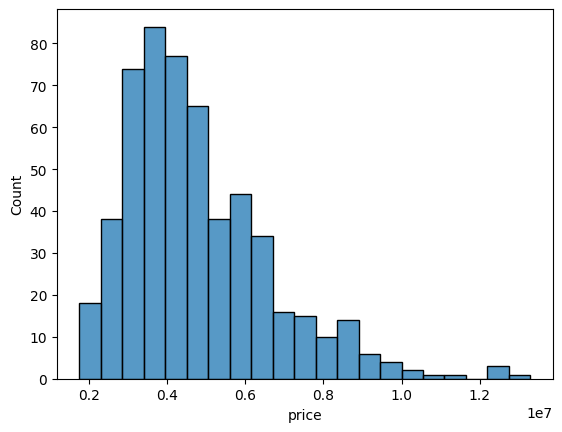

In [14]:
sns.histplot(df_encoded["price"])
print(df_encoded["price"].skew())
print(df_encoded["price"].kurt())

In [15]:
df_encoded["price_log"] = np.log1p(df_encoded["price"])

0.14086281102108905
-0.13739125863859414


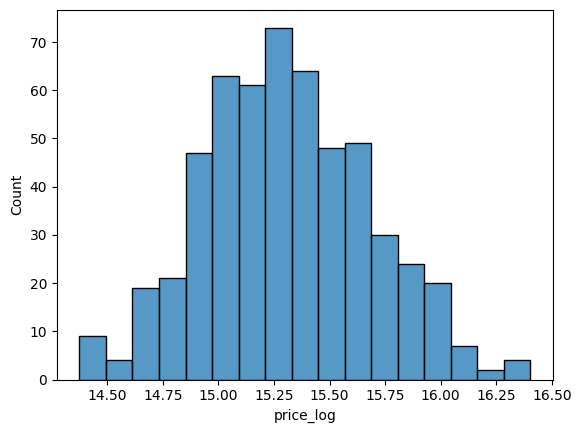

In [16]:
sns.histplot(df_encoded["price_log"])
print(df_encoded["price_log"].skew())
print(df_encoded["price_log"].kurt())

In [17]:
x = df_encoded.drop("price", axis=1)
x = df_encoded.drop("price_log", axis=1)
y = df_encoded["price_log"]

In [18]:
print(x)

        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0           0                0           

In [19]:
print(y)

0      16.403275
1      16.321037
2      16.321037
3      16.318175
4      16.250001
         ...    
540    14.414348
541    14.384879
542    14.375127
543    14.375127
544    14.375127
Name: price_log, Length: 545, dtype: float64


TEST / TRAIN SPLIT 


In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x.values, y, test_size=0.2, random_state=42)

In [21]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)


In [22]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [23]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
print(results)

     Actual Price  Predicted Price
0       15.216694        15.169575
1       15.710128        15.710226
2       15.126543        15.097012
3       15.678039        15.622352
4       14.845130        14.961863
..            ...              ...
104     16.023785        16.129173
105     15.143381        15.139261
106     15.883638        15.906833
107     15.810211        15.786262
108     15.525699        15.506817

[109 rows x 2 columns]


In [31]:
result = pd.DataFrame({
    'Actual Price': np.exp(y_test.values),
    'Predicted Price': np.exp(y_pred)
})
np.set_printoptions(suppress=True, precision=4)
print(result)

     Actual Price  Predicted Price
0       4060001.0     3.873136e+06
1       6650001.0     6.650655e+06
2       3710001.0     3.602043e+06
3       6440001.0     6.091180e+06
4       2800001.0     3.146694e+06
..            ...              ...
104     9100001.0     1.011139e+07
105     3773001.0     3.757488e+06
106     7910001.0     8.095613e+06
107     7350001.0     7.176067e+06
108     5530001.0     5.426568e+06

[109 rows x 2 columns]


In [38]:
r2_lr = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))



mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
print("R² Score:", r2_lr)
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("MSE :", mse_lr)

R² Score: 0.9346328484682691
RMSE: 0.11234613681529004
MAE : 0.07714204558254599
MSE : 0.012621654457319867


LETS APPLY RANDOM FOREST REGRESSOR IN THE MODEL 

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
rf_pred = rf.predict(x_test)

In [37]:
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))



mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
print("R² Score:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)


R² Score: 0.9985943775142533
RMSE: 0.016474517764573447
MAE : 0.004946873983154029
MSE : 0.00027140973557524613


In [33]:
result_rf = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': rf_pred
})
np.set_printoptions(suppress=True, precision=4)
print(result_rf)

     Actual Price  Predicted Price
0       15.216694        15.216982
1       15.710128        15.710946
2       15.126543        15.126706
3       15.678039        15.680178
4       14.845130        14.854544
..            ...              ...
104     16.023785        16.034393
105     15.143381        15.144192
106     15.883638        15.879889
107     15.810211        15.809600
108     15.525699        15.524788

[109 rows x 2 columns]


In [34]:
result_rf = pd.DataFrame({
    'Actual Price': np.exp(y_test).values,
    'Predicted Price': np.exp(rf_pred)
})
np.set_printoptions(suppress=True, precision=4)
print(result_rf)

     Actual Price  Predicted Price
0       4060001.0     4.061173e+06
1       6650001.0     6.655447e+06
2       3710001.0     3.710608e+06
3       6440001.0     6.453789e+06
4       2800001.0     2.826484e+06
..            ...              ...
104     9100001.0     9.197049e+06
105     3773001.0     3.776061e+06
106     7910001.0     7.880396e+06
107     7350001.0     7.345509e+06
108     5530001.0     5.524966e+06

[109 rows x 2 columns]


In [43]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest Regressor"],
    "r2score":[r2_lr,r2_rf],
    "RMSE":[rmse_lr,rmse_rf],
    "MAE":[mae_lr,mae_rf],
    "MSE":[mse_lr,mse_rf]
})

comparison

,Model,r2score,RMSE,MAE,MSE
0,Linear Regression,0.934633,0.112346,0.077142,0.012622
1,Random Forest Regressor,0.998594,0.016475,0.004947,0.000271
